# Novella Bind Score — Modeling story (Tasks 2 & 3)

This notebook **imports the real code from `src/`** (it does not re-implement anything) and tells the
modeling story end-to-end: train/test split → model & feature ranking → **ranking-capability comparison**
vs baselines and other models. Run top-to-bottom.

The headline question for this challenge is *prioritization*: **if a broker works the top of our ranked
list, how many more deals do they catch than working at random (the ~15% base rate)?**

In [1]:
import sys
from pathlib import Path
ROOT = Path.cwd()
while not (ROOT / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, roc_auc_score

from src.evaluate import get_test_scores, precision_at_k
from src.model import standardized_coefficients
from src.features import MODEL_FEATURES

fit, test, scores = get_test_scores()   # trains logistic + baselines + xgboost, scores the held-out test
y = test.label.values
base_rate = y.mean()
print(f"test rows {len(test)} | positives {int(y.sum())} ({base_rate:.1%}) | models: {list(scores)}")

test rows 578 | positives 81 (14.0%) | models: ['logistic (final)', 'agent_bind_rate only', 'outbound_chars only', 'naive: quote>effort', 'xgboost']


## 1. Train / test split (temporal)
Earliest 70% of submissions train, latest 30% test. A submission's 3 rows (t=0/7/30) stay together, and
both sides contain all `t` values.

In [2]:
train = fit["train"]
print(f"split at {fit['thr'].date()} | train {len(train)} rows / test {len(test)} rows | train base rate {fit['train_g']:.3f}")
counts = pd.DataFrame({
    "train": train.t.value_counts().sort_index(),
    "test": test.t.value_counts().sort_index(),
})
print("\nrows per t (both sides have all t):")
print(counts)

split at 2020-05-30 | train 1349 rows / test 578 rows | train base rate 0.153

rows per t (both sides have all t):
    train  test
t              
0     609   272
7     519   233
30    221    73


## 2. Model & feature ranking (Task 2)
Pooled regularized logistic regression. Feature significance via the linear lens — univariate AUC
(transform-stable) + standardized coefficients (contribution given the others).

In [3]:
uni = pd.Series({f: roc_auc_score(test.label, test[f]) for f in MODEL_FEATURES}).sort_values(ascending=False)
rank = pd.DataFrame({"univariate_test_AUC": uni, "abs_std_coef": standardized_coefficients(fit)})
rank.sort_values("univariate_test_AUC", ascending=False).round(3)

,univariate_test_AUC,abs_std_coef
agent_bind_rate,0.742,0.279
has_quote_by_t,0.567,0.276
outbound_chars_log,0.567,0.139
n_inbound_by_t,0.551,0.133
t,0.514,0.011


## Results summary — logistic vs XGBoost vs "15% guess"

The decision-relevant comparison, three models: **logistic** (shipped), **XGBoost**, and **"15% guess"** = picking
at random (its precision = the segment's base rate; its ROC-AUC = 0.5; its PR-AUC = the base rate).

**Precision@top-k leads** — it's the prioritization payoff (of the top-k submissions a broker works, what fraction
sell) — and we break it out by **t=0 / 7 / 30**, because getting good predictions *early* is the most valuable.
ROC-AUC and PR-AUC (overall + per-`t`) follow.

PRECISION @ top-k  (fraction of worked submissions that sell):
segment top_k  logistic  xgboost  15%_guess
overall   20%     0.328    0.284      0.140
overall   30%     0.264    0.253      0.140
overall   50%     0.215    0.190      0.140
    t=0   20%     0.364    0.309      0.136
    t=0   30%     0.280    0.244      0.136
    t=0   50%     0.206    0.162      0.136
    t=7   20%     0.298    0.213      0.137
    t=7   30%     0.229    0.229      0.137
    t=7   50%     0.197    0.205      0.137
   t=30   20%     0.533    0.533      0.164
   t=30   30%     0.455    0.409      0.164
   t=30   50%     0.297    0.270      0.164


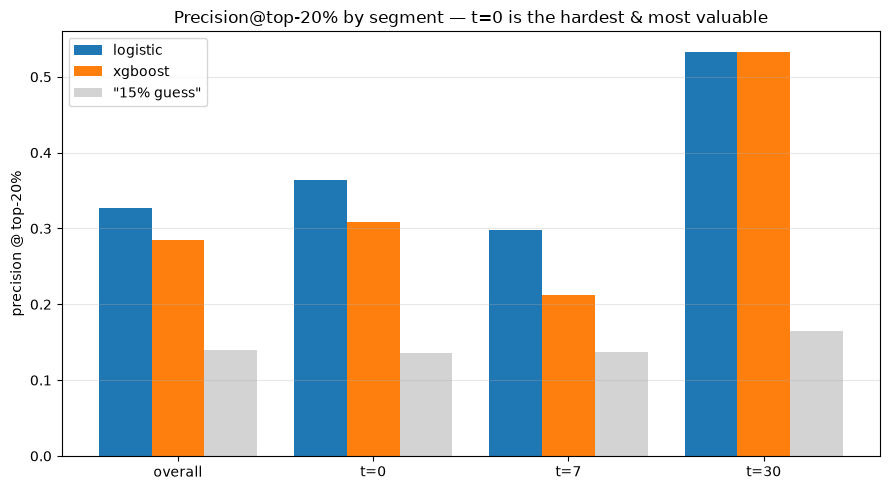


ROC-AUC & PR-AUC  (random: ROC=0.5, PR-AUC=base rate):


,segment,ROC_logistic,ROC_xgboost,PRAUC_logistic,PRAUC_xgboost,PRAUC_15%guess
0,overall,0.744,0.696,0.359,0.260,0.140
1,t=0,0.759,0.654,0.318,0.258,0.136
2,t=7,0.722,0.684,0.328,0.234,0.137
3,t=30,0.877,0.811,0.649,0.392,0.164


In [4]:
from sklearn.metrics import average_precision_score

SEG = {"overall": np.ones(len(test), bool), "t=0": (test.t == 0).values,
       "t=7": (test.t == 7).values, "t=30": (test.t == 30).values}
MODELS = {"logistic": scores["logistic (final)"], "xgboost": scores["xgboost"]}
KS = [0.20, 0.30, 0.50]

# ---- 1) Precision@top-k (the prioritization payoff) ----
rows = []
for seg, m in SEG.items():
    yy = y[m]
    for k in KS:
        rows.append({"segment": seg, "top_k": f"{int(k*100)}%",
                     "logistic": precision_at_k(yy, MODELS["logistic"][m], k),
                     "xgboost":  precision_at_k(yy, MODELS["xgboost"][m], k),
                     "15%_guess": yy.mean()})
prec = pd.DataFrame(rows)
print("PRECISION @ top-k  (fraction of worked submissions that sell):")
print(prec.round(3).to_string(index=False))

# hero chart: precision@top-20% by segment
k, segs = 0.20, list(SEG)
log_p  = [precision_at_k(y[SEG[s]], MODELS["logistic"][SEG[s]], k) for s in segs]
xgb_p  = [precision_at_k(y[SEG[s]], MODELS["xgboost"][SEG[s]], k) for s in segs]
rand_p = [y[SEG[s]].mean() for s in segs]
xpos = np.arange(len(segs)); w = 0.27
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(xpos - w, log_p, w, label="logistic", color="tab:blue")
ax.bar(xpos,     xgb_p, w, label="xgboost", color="tab:orange")
ax.bar(xpos + w, rand_p, w, label='"15% guess"', color="lightgray")
ax.set_xticks(xpos); ax.set_xticklabels(segs)
ax.set_ylabel("precision @ top-20%")
ax.set_title("Precision@top-20% by segment — t=0 is the hardest & most valuable")
ax.legend(); ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

# ---- 2) ROC-AUC & PR-AUC (overall + per t) ----
rows = []
for seg, m in SEG.items():
    yy = y[m]
    if 0 < yy.sum() < len(yy):
        rows.append({"segment": seg,
                     "ROC_logistic": roc_auc_score(yy, MODELS["logistic"][m]),
                     "ROC_xgboost":  roc_auc_score(yy, MODELS["xgboost"][m]),
                     "PRAUC_logistic": average_precision_score(yy, MODELS["logistic"][m]),
                     "PRAUC_xgboost":  average_precision_score(yy, MODELS["xgboost"][m]),
                     "PRAUC_15%guess": yy.mean()})
print("\nROC-AUC & PR-AUC  (random: ROC=0.5, PR-AUC=base rate):")
pd.DataFrame(rows).round(3)

## 3. ⭐ Cumulative gains — the prioritization story
x-axis: fraction of submissions a broker works, **sorted by our score (best first)**.
y-axis: fraction of *all* sales captured. The dashed diagonal is **random** (the ~15% base-rate world):
work 20% of the pile → catch 20% of the sales. A good model **bows above** the diagonal — work 20% and
catch far more. The bigger the gap, the better the ranking.

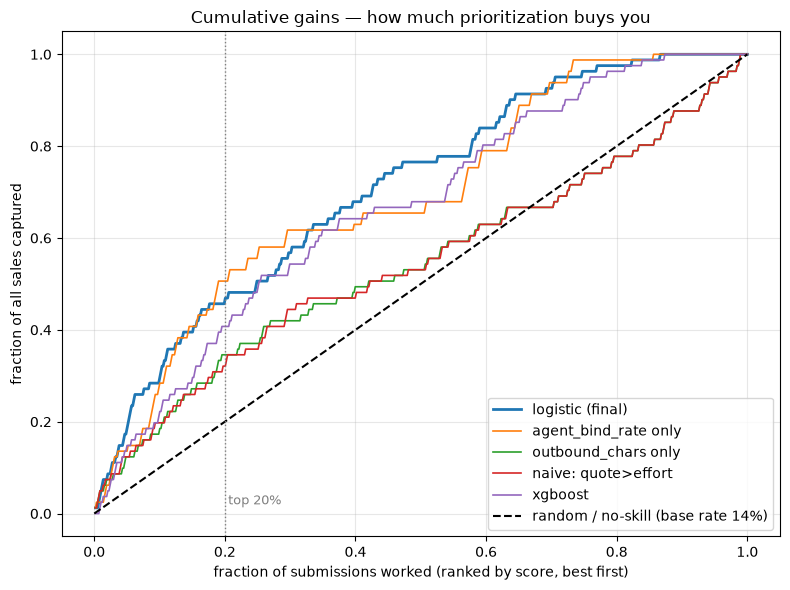

In [5]:
def gains_curve(y, s):
    order = np.argsort(-s, kind="stable")
    frac_worked = np.arange(1, len(y) + 1) / len(y)
    frac_caught = np.cumsum(y[order]) / y.sum()
    return frac_worked, frac_caught

fig, ax = plt.subplots(figsize=(8, 6))
for name, s in scores.items():
    fw, fc = gains_curve(y, s)
    ax.plot(fw, fc, lw=2 if name == "logistic (final)" else 1.2, label=name)
ax.plot([0, 1], [0, 1], "k--", lw=1.5, label=f"random / no-skill (base rate {base_rate:.0%})")
ax.axvline(0.2, color="gray", ls=":", lw=1)
ax.text(0.205, 0.02, "top 20%", color="gray", fontsize=9)
ax.set_xlabel("fraction of submissions worked (ranked by score, best first)")
ax.set_ylabel("fraction of all sales captured")
ax.set_title("Cumulative gains — how much prioritization buys you")
ax.legend(loc="lower right"); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 4. Precision@k — hit-rate vs the 15% base rate
Same ranking, different lens. x-axis: fraction worked (best first). y-axis: **hit-rate** = of the ones you
worked, what % sold. **Random is the flat dashed line at the base rate (~15%)** — picking at random sells at
15% no matter how deep you go. A good model **starts high** (top-scored ones sell a lot) and **decays toward
15%**. The gap at *top-20%* is our headline precision-vs-baseline.

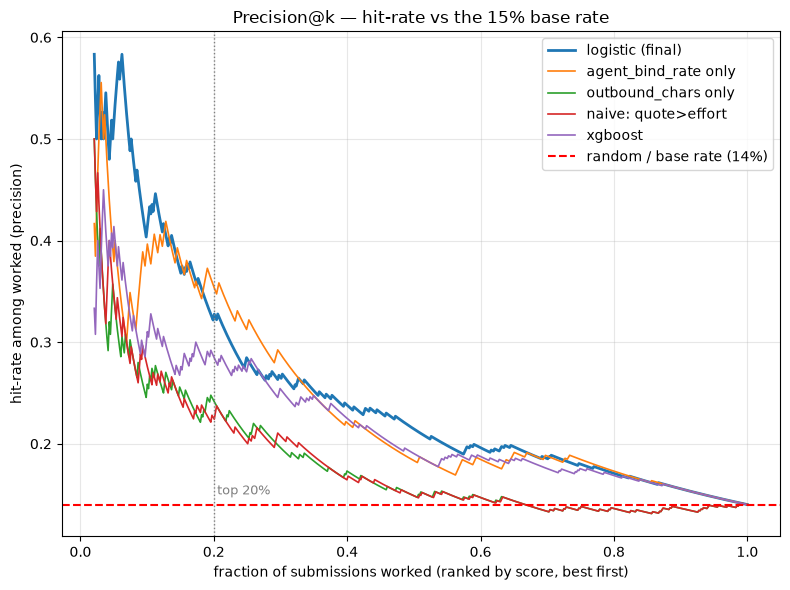

In [6]:
def precision_curve(y, s, min_frac=0.02):
    order = np.argsort(-s, kind="stable")
    k = np.arange(1, len(y) + 1)
    prec = np.cumsum(y[order]) / k          # hit-rate among the top-k
    frac = k / len(y)
    m = frac >= min_frac                     # skip the noisy first few rows
    return frac[m], prec[m]

fig, ax = plt.subplots(figsize=(8, 6))
for name, s in scores.items():
    fw, pc = precision_curve(y, s)
    ax.plot(fw, pc, lw=2 if name == "logistic (final)" else 1.2, label=name)
ax.axhline(base_rate, color="red", ls="--", lw=1.5, label=f"random / base rate ({base_rate:.0%})")
ax.axvline(0.2, color="gray", ls=":", lw=1)
ax.text(0.205, base_rate + 0.01, "top 20%", color="gray", fontsize=9)
ax.set_xlabel("fraction of submissions worked (ranked by score, best first)")
ax.set_ylabel("hit-rate among worked (precision)")
ax.set_title("Precision@k — hit-rate vs the 15% base rate")
ax.legend(loc="upper right"); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 5. ROC curves (overall ranking quality)
The ML-standard view. Area under the curve = ROC-AUC; the diagonal is random (0.5).

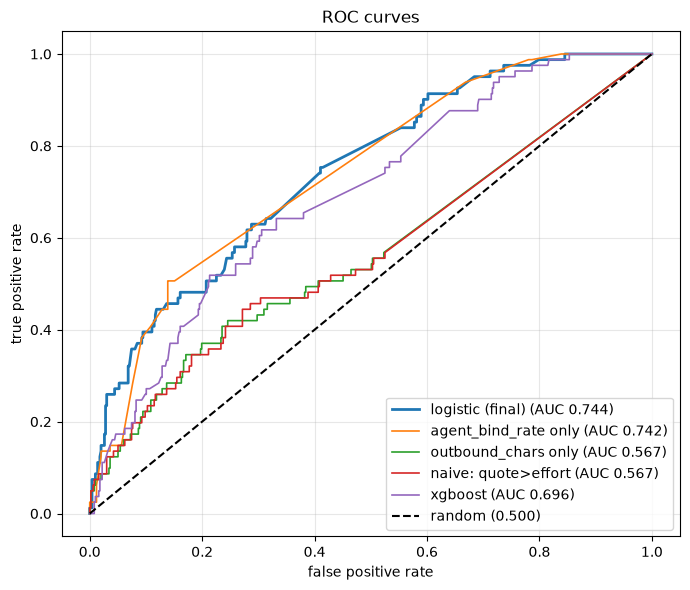

In [7]:
fig, ax = plt.subplots(figsize=(7, 6))
for name, s in scores.items():
    fpr, tpr, _ = roc_curve(y, s)
    ax.plot(fpr, tpr, lw=2 if name == "logistic (final)" else 1.2, label=f"{name} (AUC {auc(fpr, tpr):.3f})")
ax.plot([0, 1], [0, 1], "k--", lw=1.5, label="random (0.500)")
ax.set_xlabel("false positive rate"); ax.set_ylabel("true positive rate")
ax.set_title("ROC curves"); ax.legend(loc="lower right"); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 7. Per-`t` — the day-0 rescue
Early prediction is the most valuable. `outbound_chars` alone is blind at t=0 (nothing sent yet); the model
stays useful because **customer track record** is known from day 0.

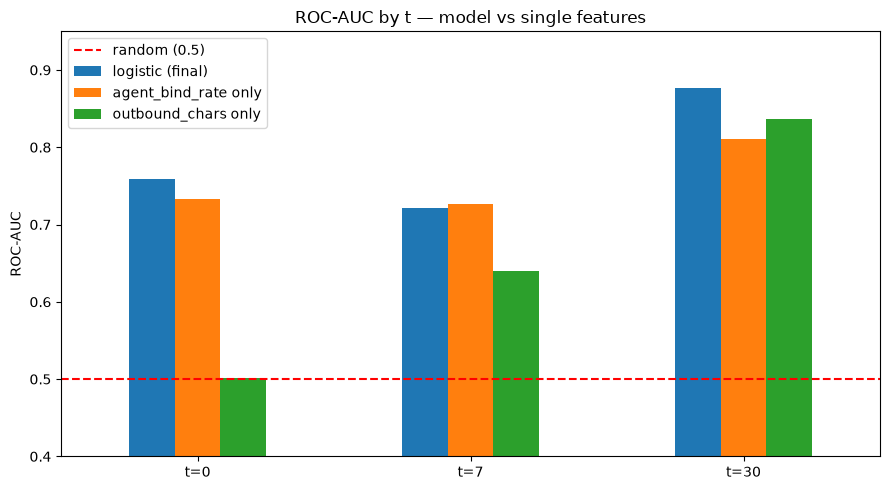

,logistic (final),agent_bind_rate only,outbound_chars only
t=0,0.759,0.733,0.501
t=7,0.722,0.727,0.639
t=30,0.877,0.810,0.836


In [8]:
ts = [0, 7, 30]
show = ["logistic (final)", "agent_bind_rate only", "outbound_chars only"]
data = {}
for name in show:
    data[name] = [roc_auc_score(test.label.values[(test.t == t).values], scores[name][(test.t == t).values]) for t in ts]
dfp = pd.DataFrame(data, index=[f"t={t}" for t in ts])
ax = dfp.plot.bar(figsize=(9, 5), rot=0)
ax.axhline(0.5, color="red", ls="--", label="random (0.5)")
ax.set_ylabel("ROC-AUC"); ax.set_ylim(0.4, 0.95); ax.set_title("ROC-AUC by t — model vs single features")
ax.legend(loc="upper left"); plt.tight_layout(); plt.show()
dfp.round(3)

## Conclusions
- The logistic bind-score **ranks well** (ROC-AUC ~0.74) and delivers **2–3× lift** at the top of the list —
  the gains curve bows well above the random diagonal, and precision@top-20% sits far above the 15% base rate.
- **Customer track record (`agent_bind_rate`) carries most of the signal** and **rescues day-0**, where
  activity-based features are blind.
- **Logistic beats XGBoost**, and one pooled model matches three per-`t` models — the signal is simple, so
  simple + interpretable wins. (Full numbers + caveats in `reports/03_model_evaluation.md`.)